In [1]:
import json
import math
import configparser

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from functools import lru_cache
from scipy.special import i1e, loggamma
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import ImageGrid

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False

%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

m_0 = 1.0
M_0 = 1e30
N_0 = M_0 / m_0
lambda_0 = 1.0 / M_0

def rect_inches(fig, left, bottom, width, height):
    fw, fh = fig.get_size_inches()
    return [left/fw, bottom/fh, width/fw, height/fh]

def const_w1_logmass(data, tau, m0):

    m = data["par_size"]**3
    w = data["par_numr"]*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = "right")
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]

    g = 1.0 / (1.0 + tau / 2.0)
    k = np.ceil(10.0**x).astype(np.int64) - 1

    F_ana = np.zeros_like(x)
    valid = k >= 1
    F_ana[valid] = -np.expm1(k[valid]*np.log1p(-g) + np.log1p(k[valid]*g))

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_const(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_const/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = float(config["PARAMETERS"]["DT_OUT"])*int(config["PARAMETERS"]["LOG_BASE"])**frame

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)
    
    return const_w1_logmass(data, tau, m_0)

@lru_cache(maxsize = None)
def linear_mass_cdf(tau):

    x_eval = np.linspace(-0.5, 9.5, 4097)
    x_work = np.linspace(-12.0, 12.0, 65537)
    mu = 10.0**x_work

    g = np.exp(-tau)
    sqrt_1mg = np.sqrt(1.0 - g)
    arg = 2.0*mu*sqrt_1mg
    decay = g/(1.0 + sqrt_1mg)
    exponent = -mu*decay**2

    p_logmass = np.log(10.0)*mu*g*i1e(arg)*np.exp(exponent)/sqrt_1mg

    cdf_work = np.empty_like(x_work)
    cdf_work[0] = 0.0
    cdf_work[1:] = np.cumsum(0.5*(p_logmass[:-1] + p_logmass[1:])*np.diff(x_work))
    cdf_work /= cdf_work[-1]

    return np.interp(x_eval, x_work, cdf_work)

def linear_w1_logmass(data, tau, m0):

    m = data['par_size']**3
    w = data['par_numr']*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = 'right')
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]
    F_ana = linear_mass_cdf(float(tau))

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_linear(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_linear/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = frame*float(config['PARAMETERS']['DT_OUT'])

    dtype = np.dtype([(name, value) for name, value in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)

    return linear_w1_logmass(data, tau, m0 = 1.0)

@lru_cache(maxsize = None)
def product_mass_cdf(tau, k_max = 100_000):

    probability = np.empty(k_max)

    # p_k = exp(-k*tau) * (k*tau)^(k-1) / k!
    probability[0] = np.exp(-tau)

    factor = tau*np.exp(-tau)

    for k in range(1, k_max):
        probability[k] = (probability[k - 1]*factor*np.exp((k - 1)*np.log1p(1.0/k)))

    return np.cumsum(probability)

def product_w1_logmass(data, tau, m0):

    m = data["par_size"]**3
    w = data["par_numr"]*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = "right")
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]

    k_below = np.ceil(10.0**x).astype(np.int64) - 1
    cdf = product_mass_cdf(float(tau))

    F_ana = np.zeros_like(x)
    valid = k_below >= 1
    F_ana[valid] = cdf[np.minimum(k_below[valid], len(cdf)) - 1]

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_product(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_product/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + "variables.txt")

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = float(config["PARAMETERS"]["DT_OUT"])*frame

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)

    return product_w1_logmass(data, tau, m_0)

def get_mass (size): return size*size*size

def const_kernel (m, N_0, M_0, m_0, Lambda, t):
    h = 0.5*M_0*Lambda*t
    g = 1.0/(1.0+h)
    f = N_0*g*g*(1.0-g)**(m/m_0-1.0)
    return f*m*m / M_0 / m_0

def init_dist (m, N_0, M_0, m_0):
    f = N_0*np.exp(-m/m_0)/m_0
    return f*m*m / M_0 / m_0

def linear_kernel (m, N_0, M_0, m_0, Lambda, t):
    tau = M_0*Lambda*t
    g = np.exp(-tau)
    # Use exponentially scaled Bessel: i1e(x) = i1(x)*exp(-|x|)
    # This avoids overflow: i1(x)*exp(y) = i1e(x)*exp(x+y)
    arg = 2.0*m/m_0*np.sqrt(1.0-g)
    exponent = arg - m/m_0*(2.0-g)  # Combine exponentials
    f = N_0/m*(g/np.sqrt(1.0-g))*i1e(arg)*np.exp(exponent)
    return f*m*m / M_0 / m_0

def product_kernel (m, N_0, M_0, m_0, Lambda, t):
    eta = N_0*Lambda*t
    k = m / m_0
    # Work in log-space to avoid overflow
    # log(f) = log(N_0) + (k-1)*log(2*k) - log(k) - loggamma(k+1) + (k-1)*log(0.5*eta) - k*eta
    log_f = np.log(N_0) + (k-1.0)*np.log(2.0*k) - np.log(k) - loggamma(k+1.0) + (k-1.0)*np.log(0.5*eta) - k*eta
    # f*m*m = exp(log_f + 2*log(m))
    return np.exp(log_f + 2.0*np.log(m)) / M_0 / m_0

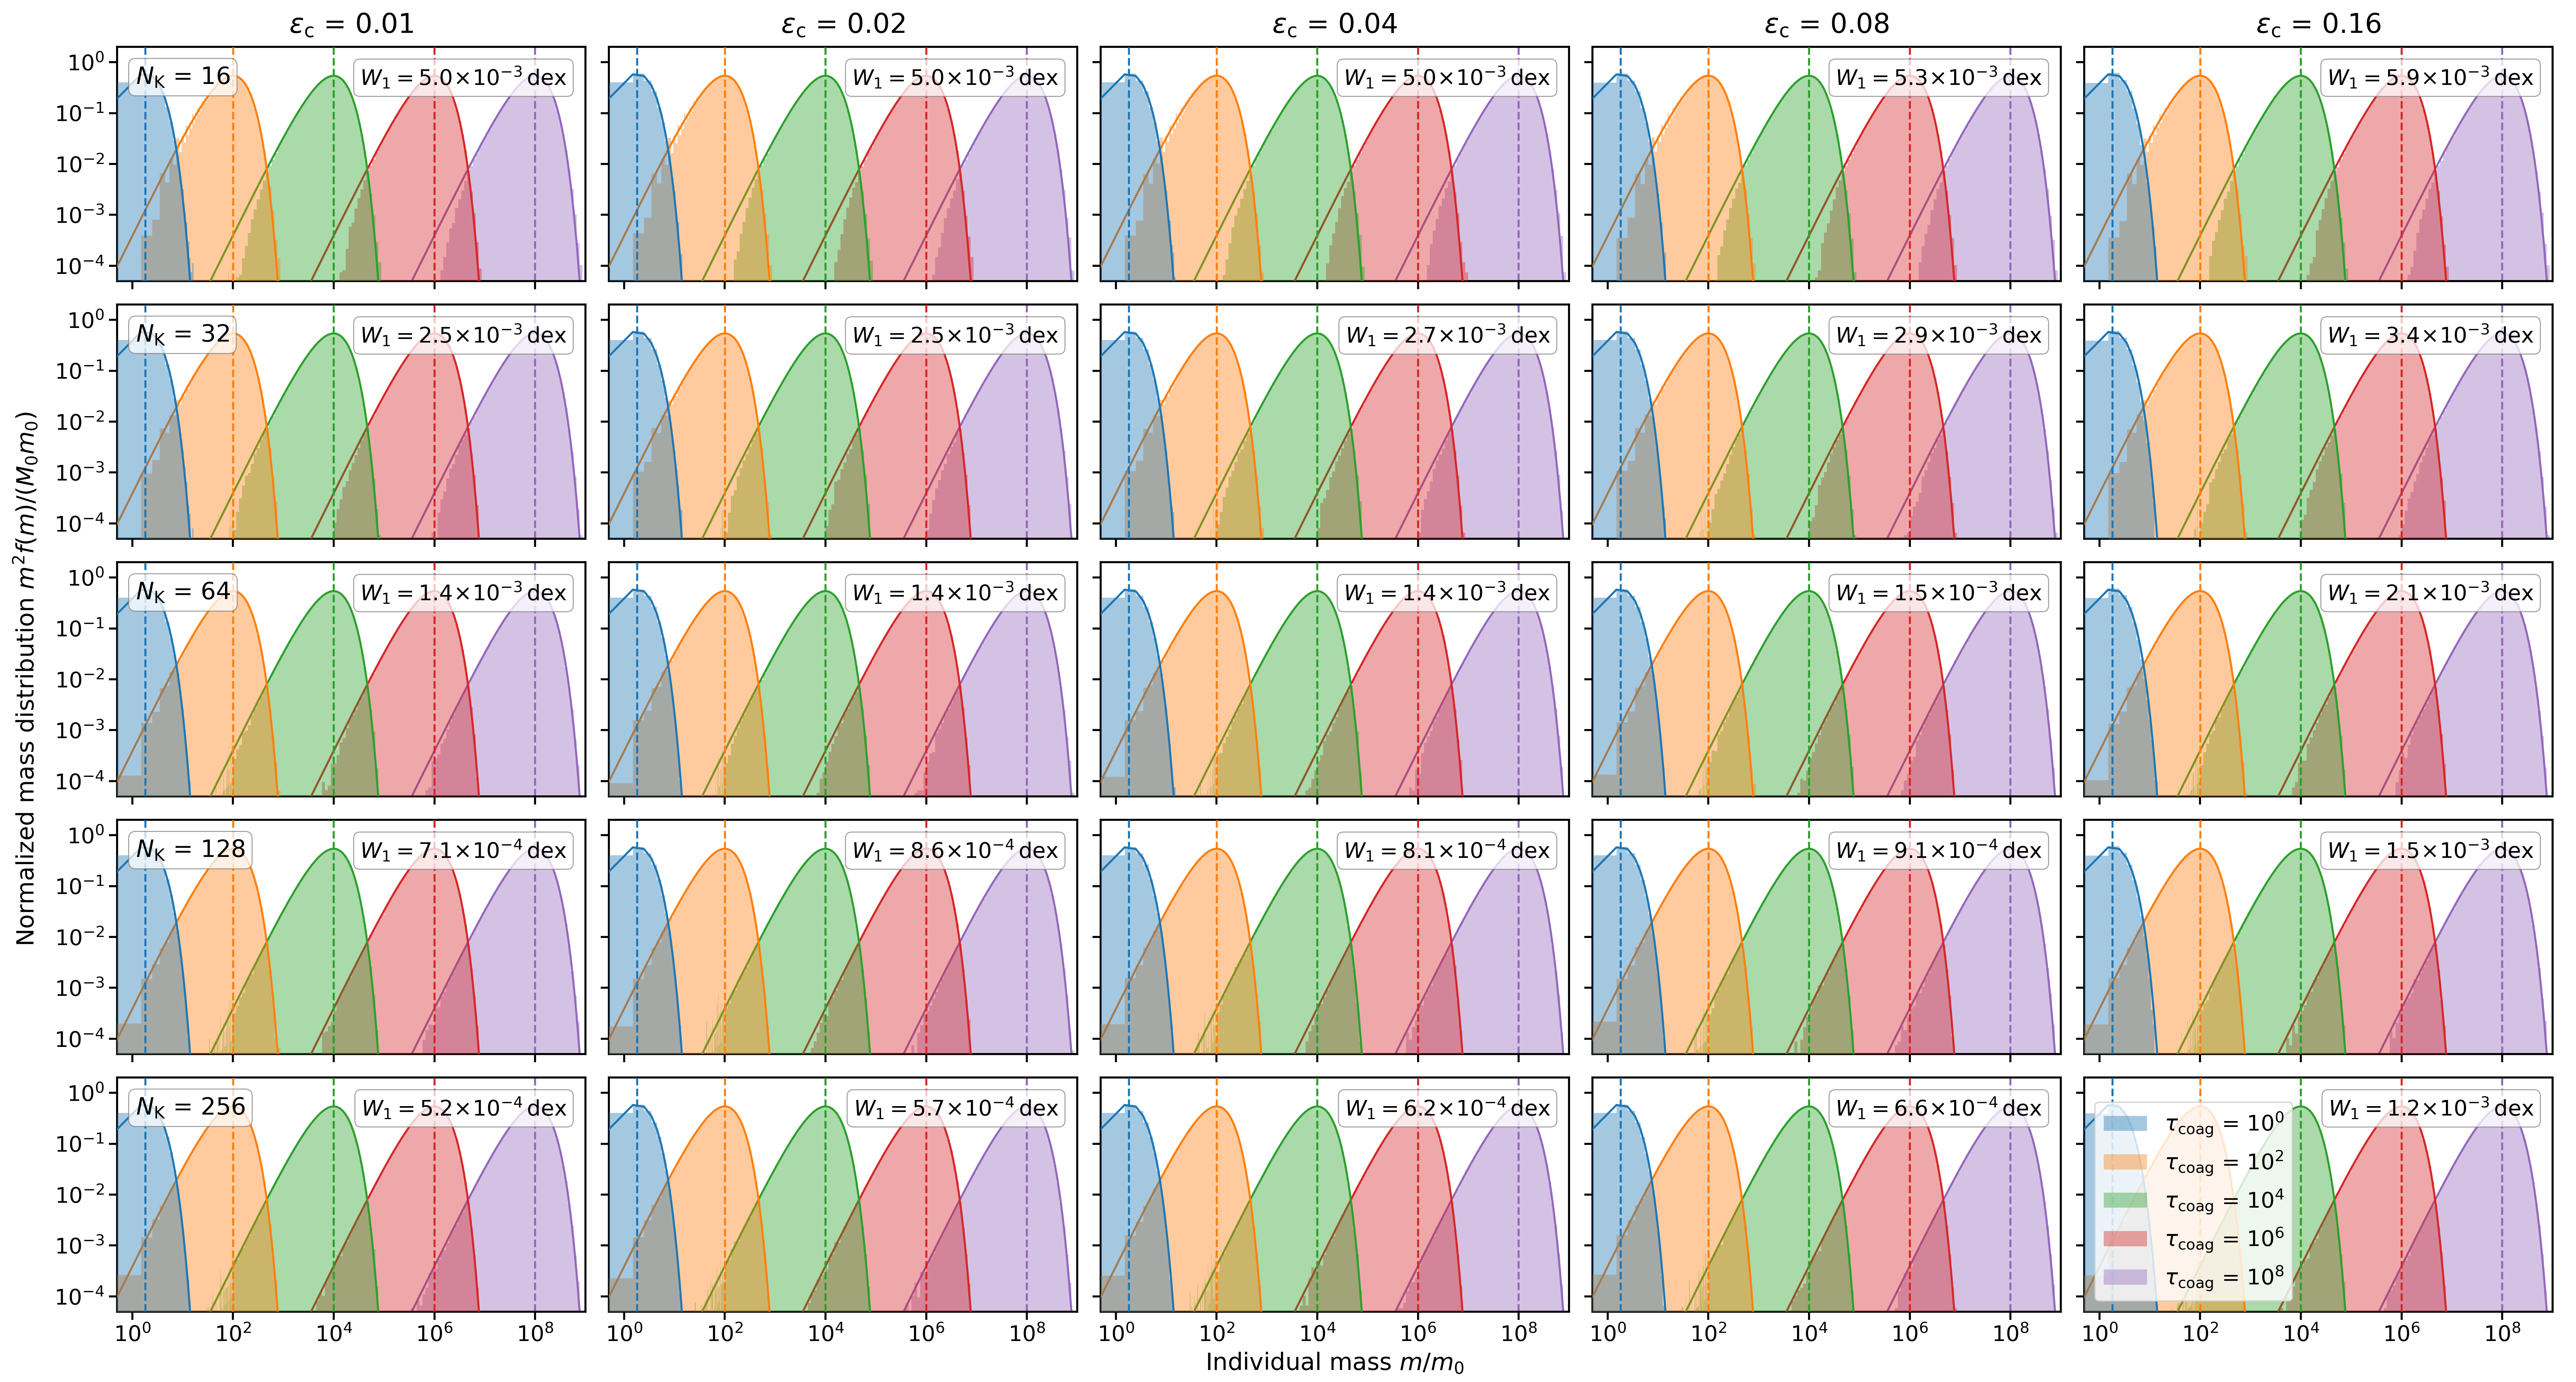

In [2]:
# const kernel

k_values = [16, 32, 64, 128, 256]
b_values = [0.01, 0.02, 0.04, 0.08, 0.16]
model_list = [f"k{k}_eps{b:.2f}".replace(".", "p") for k, b in product(k_values, b_values)]

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/const/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.48
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = root / model / 'seed0'
    path_model = str(path_model) + '/'

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-1, 1e9
    y_min, y_max = 5e-5, 2e0

    k_switch = 100
    integer_edges = np.arange(0.5, k_switch + 1.5, 1.0)
    log_edges = np.geomspace(integer_edges[-1], x_max, 120)
    x_bins = np.concatenate([integer_edges, log_edges[1:]])

    xticks = [1e0, 1e2, 1e4, 1e6, 1e8]
    xtick_labels = ['$10^{:d}$'.format(int(np.log10(x))) for x in xticks]
    yticks = [1e-4, 1e-3, 1e-2, 1e-1, 1e0]
    ytick_labels = ['$10^{{{:d}}}$'.format(int(np.log10(y))) for y in yticks]

    idx_file = [1,3,5,7,9]
    for i, snapshot in enumerate(idx_file):

        time = 10**(snapshot - 1)
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        mu_peak = -2.0 / np.log1p(-1.0 / (1.0 + 0.5*time))
        axs[idx_mod].axvline(x = mu_peak, ls = '--', c = f'C{i}', lw = linewidth, zorder = 2*(len(idx_file)-i))
        analytical = const_kernel(x_bins, N_0, M_0, m_0, lambda_0, time)
        axs[idx_mod].plot(x_bins, analytical,        c = f'C{i}', lw = linewidth, zorder = 2*(len(idx_file)-i))

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(hist[0] / np.diff(np.log(x_bins)), hist[1], 
            color = f'C{i}', fill = 1, alpha = 0.4, zorder = 2*(len(idx_file)-i)-1,
            label = f'$\\tau_\\mathrm{{coag}}$ = $10^{snapshot - 1:d}$'
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_yticks(yticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].set_yticklabels(ytick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].xaxis.set_minor_locator(NullLocator())
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right', zorder = 2*len(idx_file)+1
    )

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, '$N_\\mathrm{{K}}$ = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = 1.1*fontsize, va = 'top', ha = 'left', zorder = 2*len(idx_file)+1
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('$\\epsilon_\\mathrm{{c}}$ = {}'.format(eps), fontsize = 1.25*fontsize, pad = 10)

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize).set_zorder(2*len(idx_file)+1)
        
fig.supxlabel('Individual mass $m/m_0$',                         fontsize = 1.1*fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = 1.1*fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()

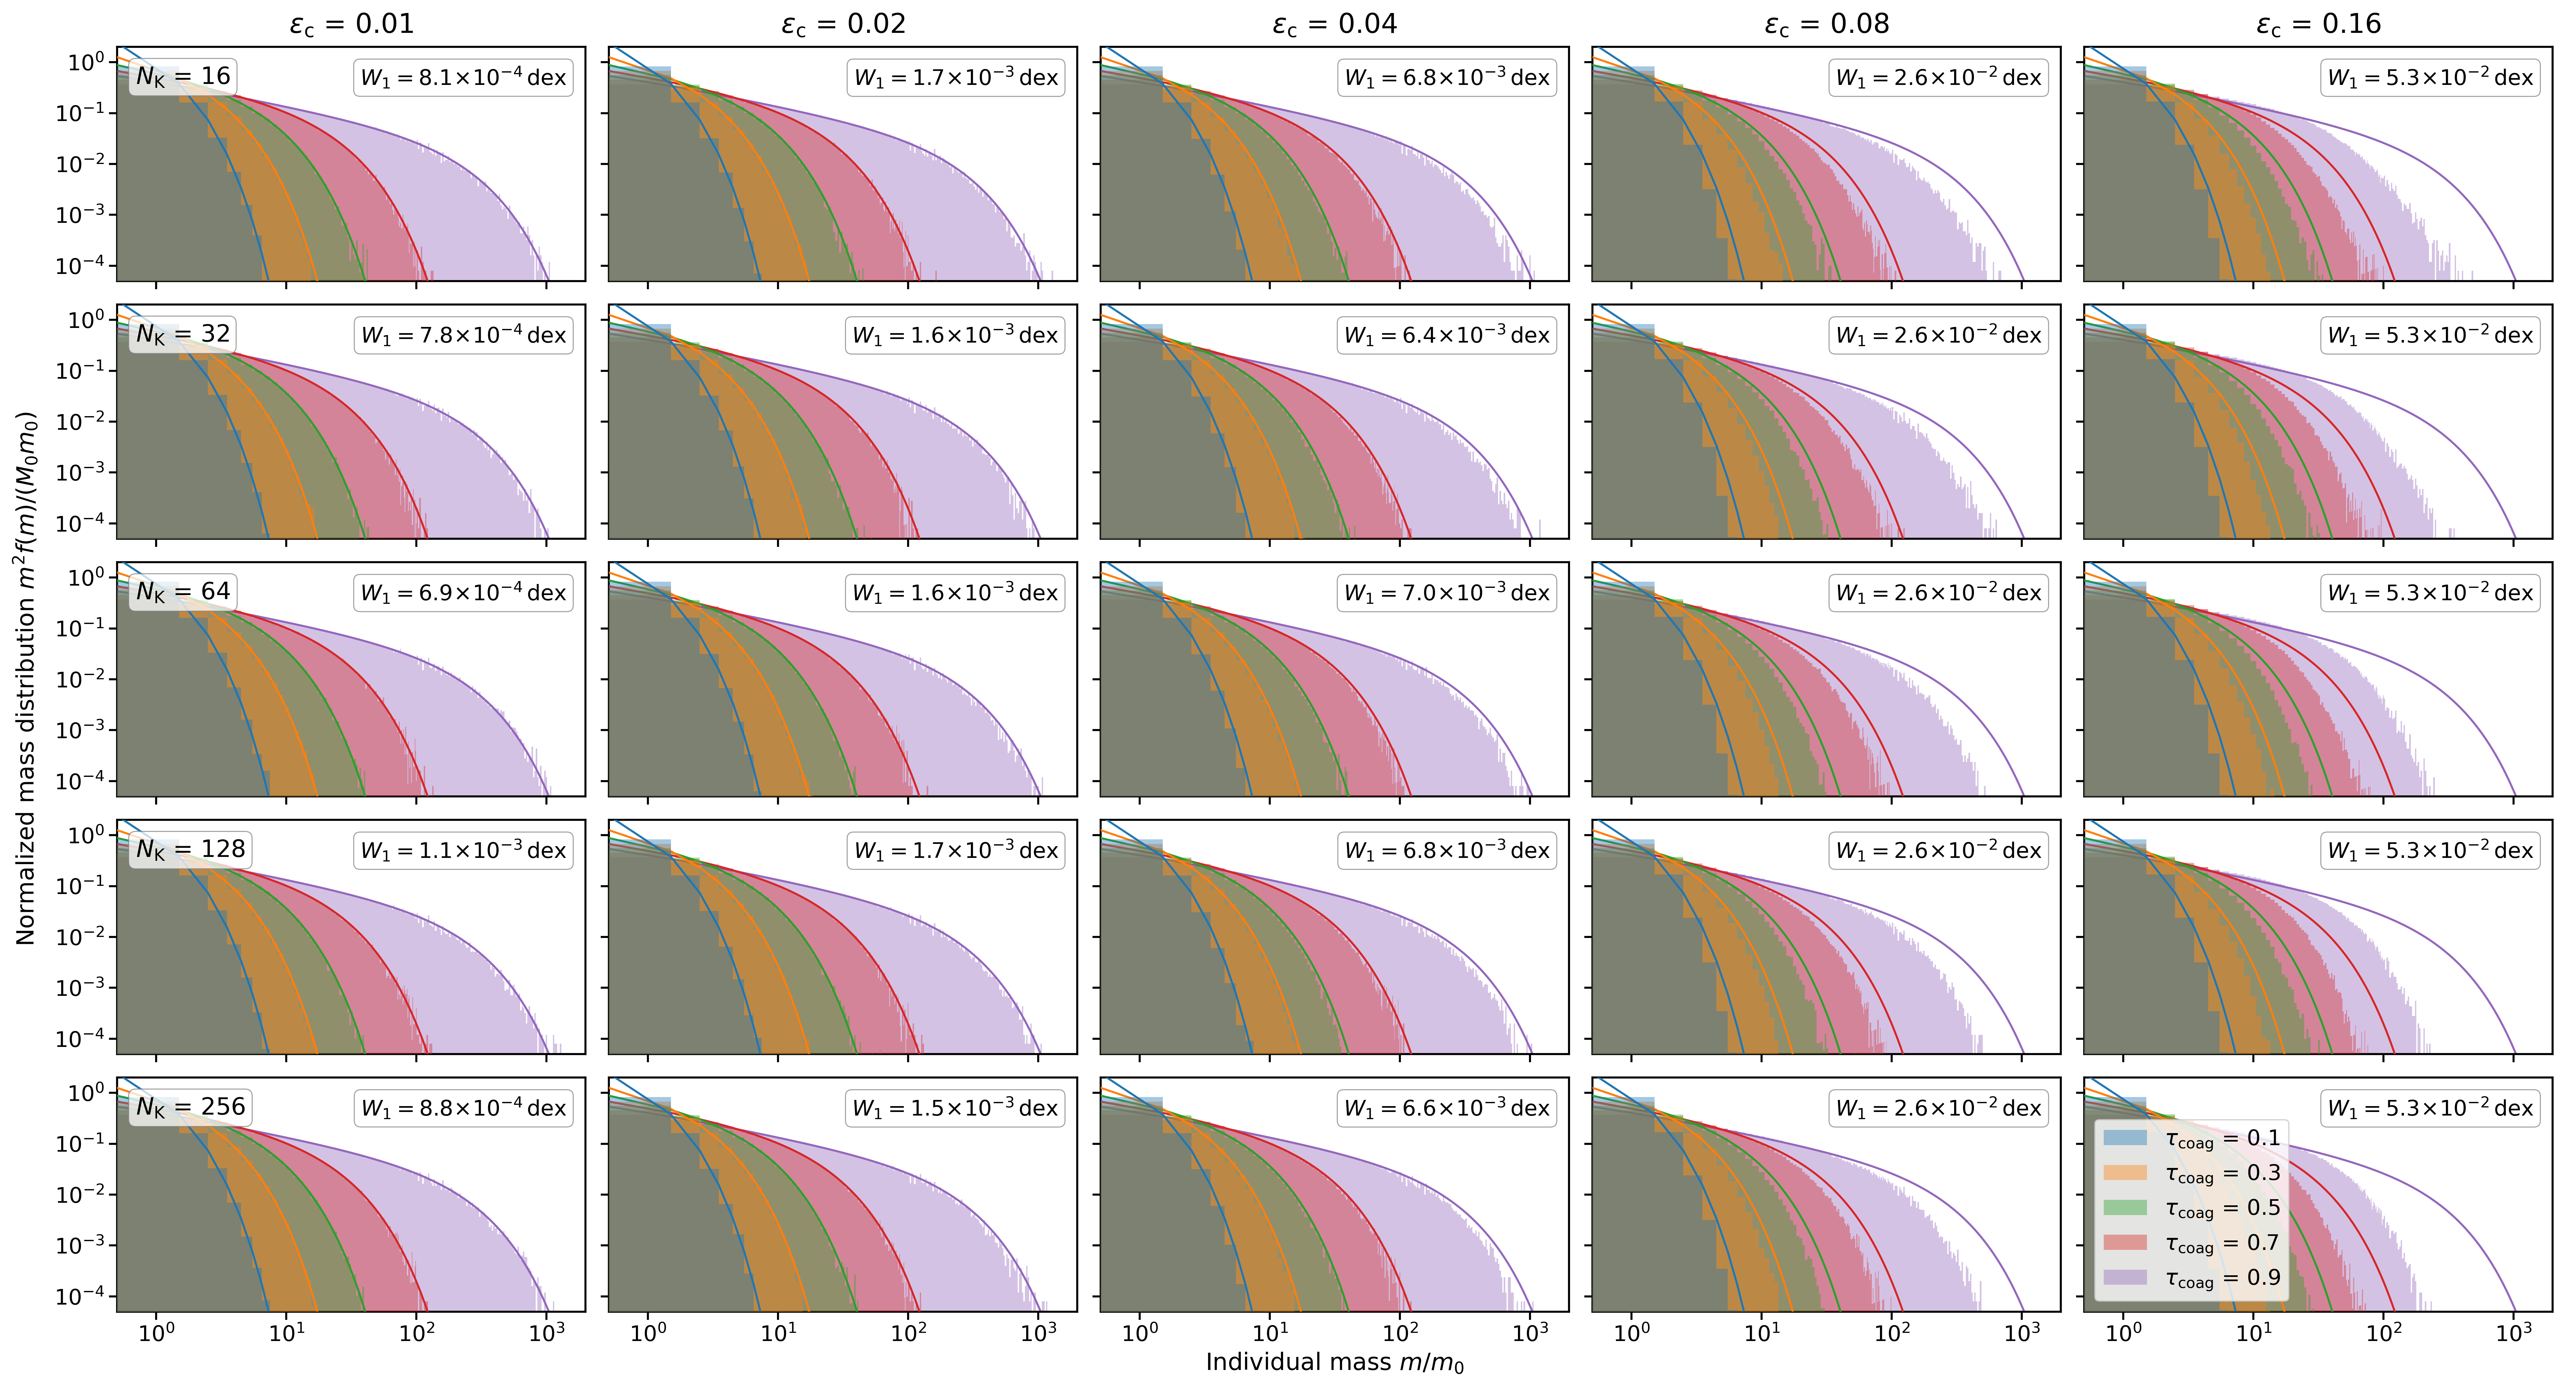

In [3]:
# product kernel

k_values = [16, 32, 64, 128, 256]
b_values = [0.01, 0.02, 0.04, 0.08, 0.16]
model_list = [f"k{k}_eps{b:.2f}".replace(".", "p") for k, b in product(k_values, b_values)]

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/product/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.48
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = root / model / 'seed0'
    path_model = str(path_model) + '/'

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-1, 2e3
    y_min, y_max = 5e-5, 2e0

    k_switch = 100
    integer_edges = np.arange(0.5, k_switch + 1.5, 1.0)
    log_edges = np.geomspace(integer_edges[-1], x_max, 120)
    x_bins = np.concatenate([integer_edges, log_edges[1:]])

    xticks = [1e0, 1e1, 1e2, 1e3]
    xtick_labels = ['$10^{:d}$'.format(int(np.log10(x))) for x in xticks]
    yticks = [1e-4, 1e-3, 1e-2, 1e-1, 1e0]
    ytick_labels = ['$10^{{{:d}}}$'.format(int(np.log10(y))) for y in yticks]

    idx_file = [1,3,5,7,9]
    for i, snapshot in enumerate(idx_file):

        time = float(config["PARAMETERS"]["DT_OUT"])*snapshot
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        analytical = product_kernel(x_bins, N_0, M_0, m_0, lambda_0, time)
        axs[idx_mod].plot(x_bins, analytical, c = f'C{i}', lw = linewidth, zorder = 2*(len(idx_file)-i))

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(hist[0] / np.diff(np.log(x_bins)), hist[1], 
            color = f'C{i}', fill = 1, alpha = 0.4, zorder = 2*(len(idx_file)-i)-1,
            label = f'$\\tau_\\mathrm{{coag}}$ = {time:.1f}'
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_yticks(yticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].set_yticklabels(ytick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].xaxis.set_minor_locator(NullLocator())
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right', zorder = 2*len(idx_file)+1
    )

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, '$N_\\mathrm{{K}}$ = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = 1.1*fontsize, va = 'top', ha = 'left', zorder = 2*len(idx_file)+1
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('$\\epsilon_\\mathrm{{c}}$ = {}'.format(eps), fontsize = 1.25*fontsize, pad = 10)

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize).set_zorder(2*len(idx_file)+1)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = 1.1*fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = 1.1*fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()

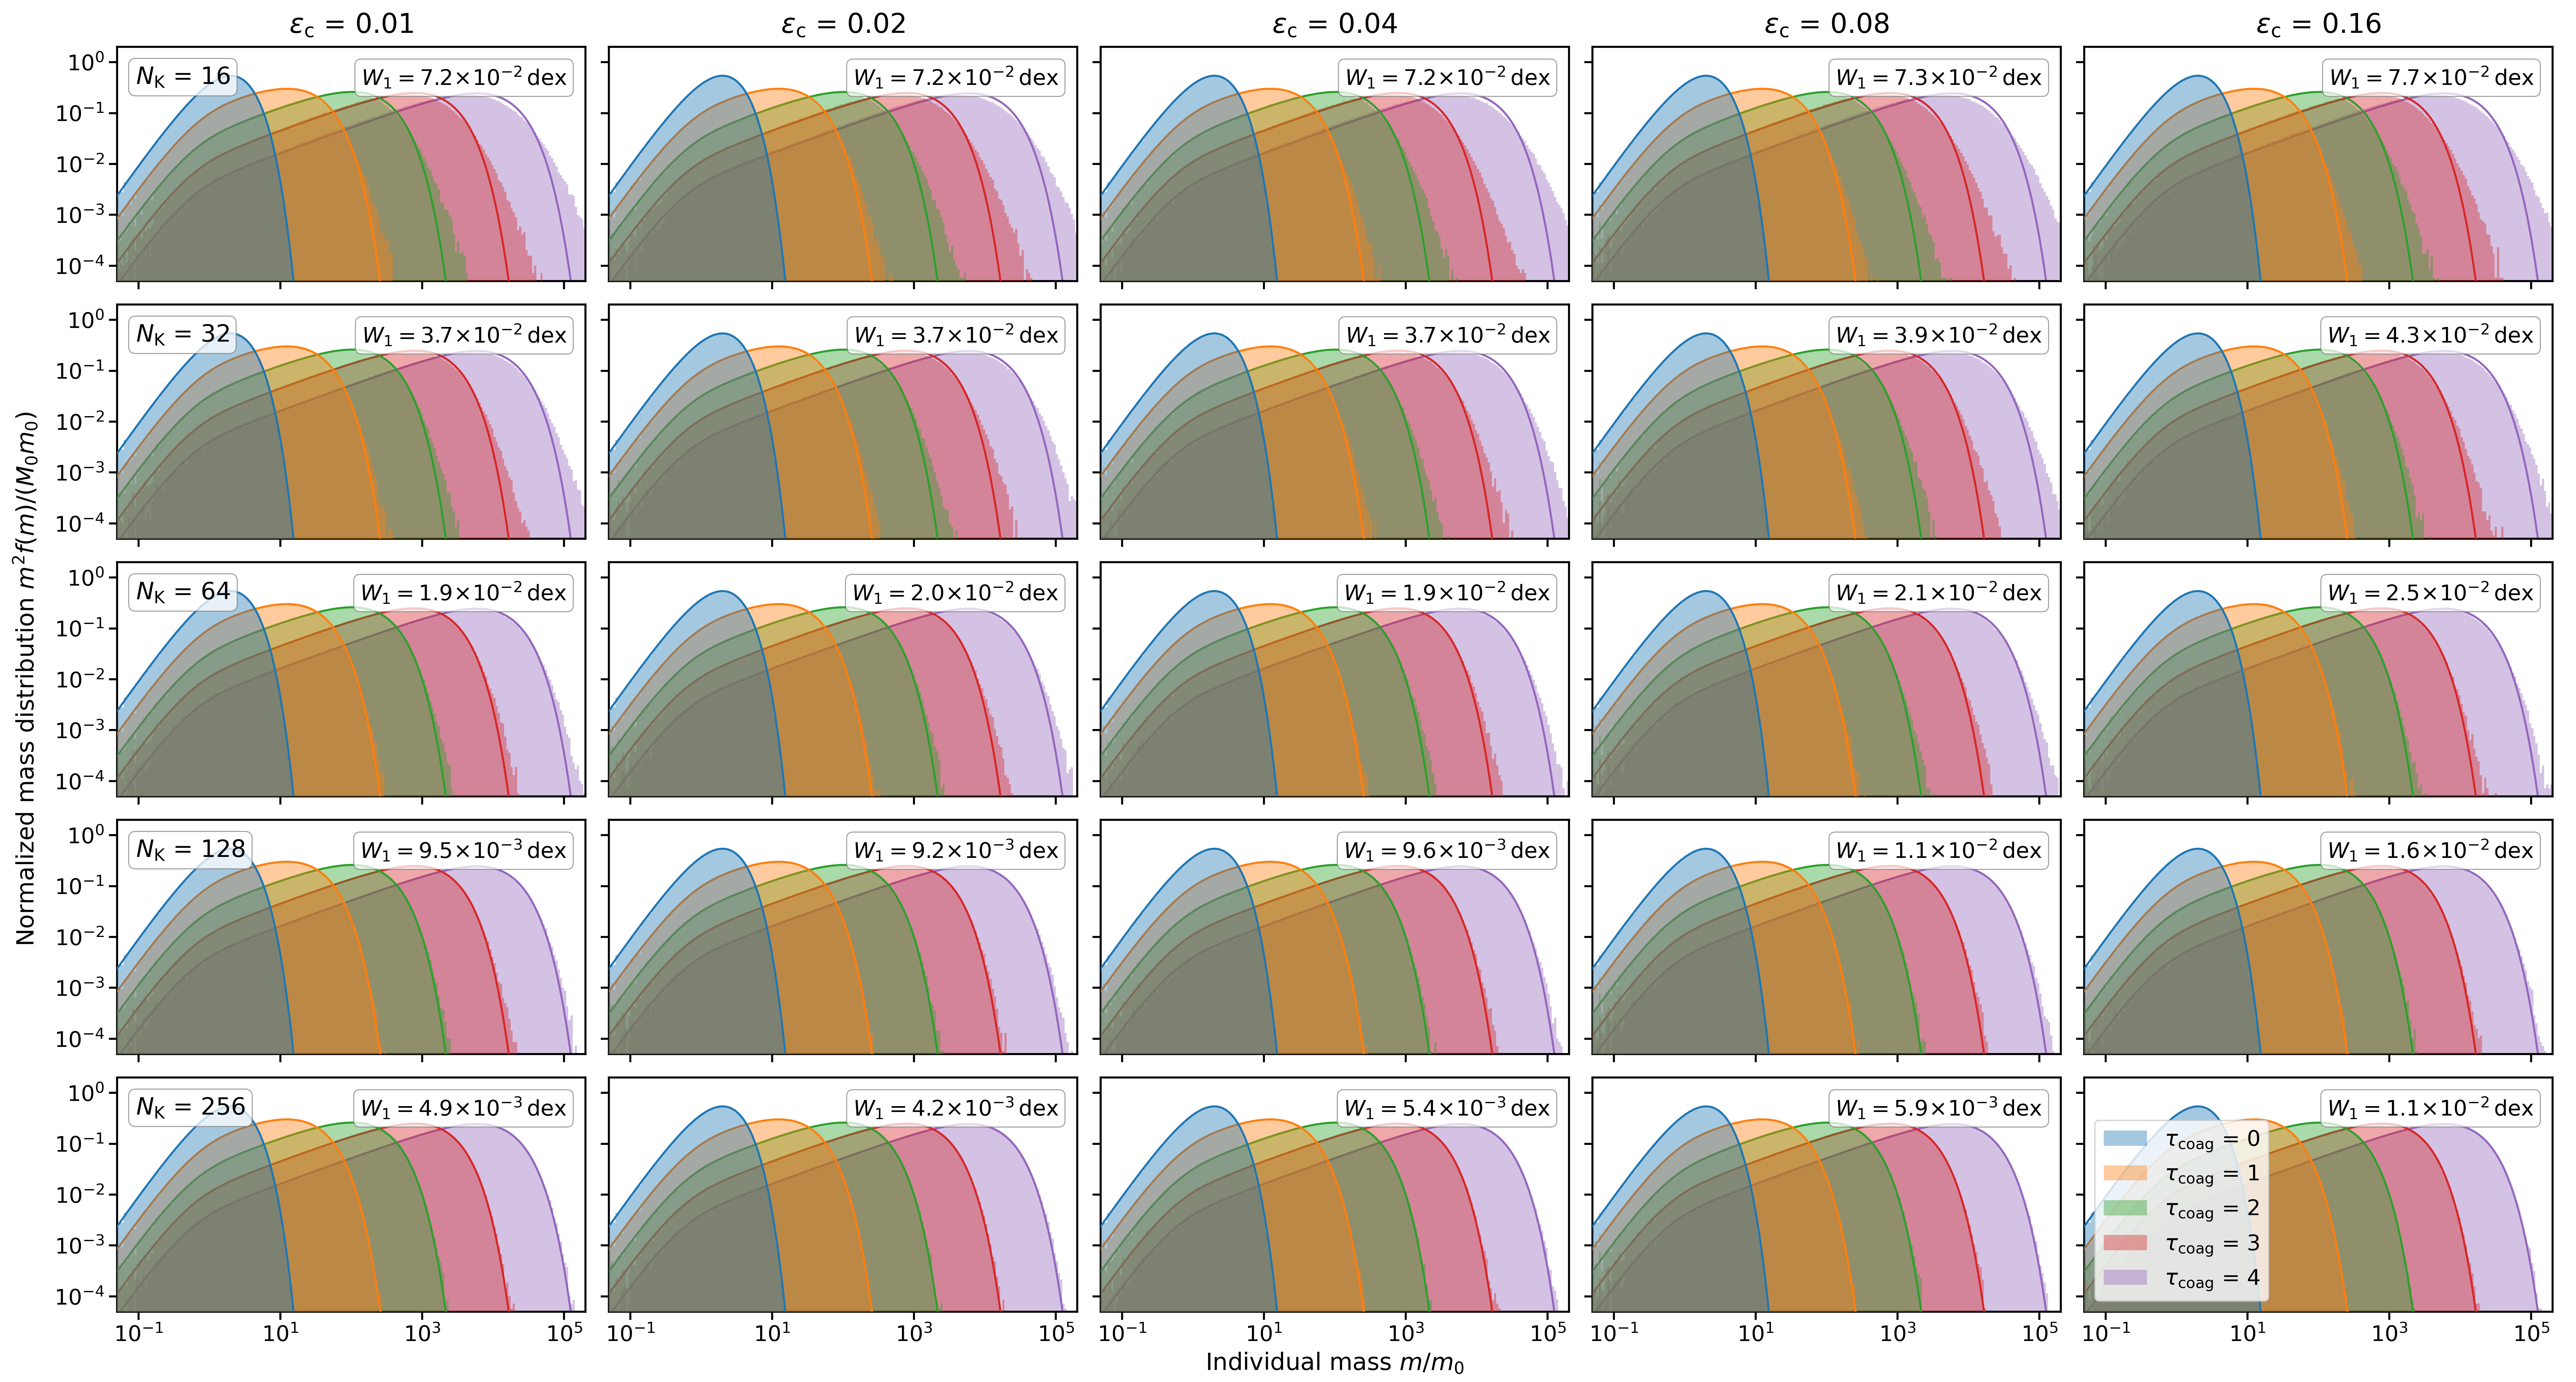

In [9]:
# linear kernel

k_values = [16, 32, 64, 128, 256]
b_values = [0.01, 0.02, 0.04, 0.08, 0.16]
model_list = [f"k{k}_eps{b:.2f}".replace(".", "p") for k, b in product(k_values, b_values)]

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/linear/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.48
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = root / model / 'seed0'
    required = ['variables.txt'] + [f'particle_{i:05d}.dat' for i in range(5)]

    if model not in model_stats or not all((path_model / f).is_file() for f in required):
        axs[idx_mod].set_axis_off()
        continue

    path_model = str(path_model) + '/'

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-2, 2e5
    y_min, y_max = 5e-5, 2e0
    x_bins = np.geomspace(x_min, x_max, 220)

    xticks = [1e-1, 1e1, 1e3, 1e5]
    xtick_labels = ['$10^{{{:d}}}$'.format(int(np.log10(x))) for x in xticks]
    yticks = [1e-4, 1e-3, 1e-2, 1e-1, 1e0]
    ytick_labels = ['$10^{{{:d}}}$'.format(int(np.log10(y))) for y in yticks]

    idx_file = [0,1,2,3,4]
    for i, snapshot in enumerate(idx_file):

        time = float(config["PARAMETERS"]["DT_OUT"])*snapshot
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        analytical = init_dist(m_0*x_bins, N_0, M_0, m_0) if snapshot == 0 else linear_kernel(m_0*x_bins, N_0, M_0, m_0, lambda_0, time)
        axs[idx_mod].plot(x_bins, analytical, c = f'C{i}', lw = linewidth, zorder = 2*(len(idx_file)-i))

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(hist[0] / np.diff(np.log(x_bins)), hist[1], 
            color = f'C{i}', fill = 1, alpha = 0.4, zorder = 2*(len(idx_file)-i)-1,
            label = f'$\\tau_\\mathrm{{coag}}$ = {time:.0f}'
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_yticks(yticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].set_yticklabels(ytick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].xaxis.set_minor_locator(NullLocator())
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right', zorder = 2*len(idx_file)+1
    )

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, '$N_\\mathrm{{K}}$ = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = 1.1*fontsize, va = 'top', ha = 'left', zorder = 2*len(idx_file)+1
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('$\\epsilon_\\mathrm{{c}}$ = {}'.format(eps), fontsize = 1.25*fontsize, pad = 10)

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize).set_zorder(2*len(idx_file)+1)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = 1.1*fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = 1.1*fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()

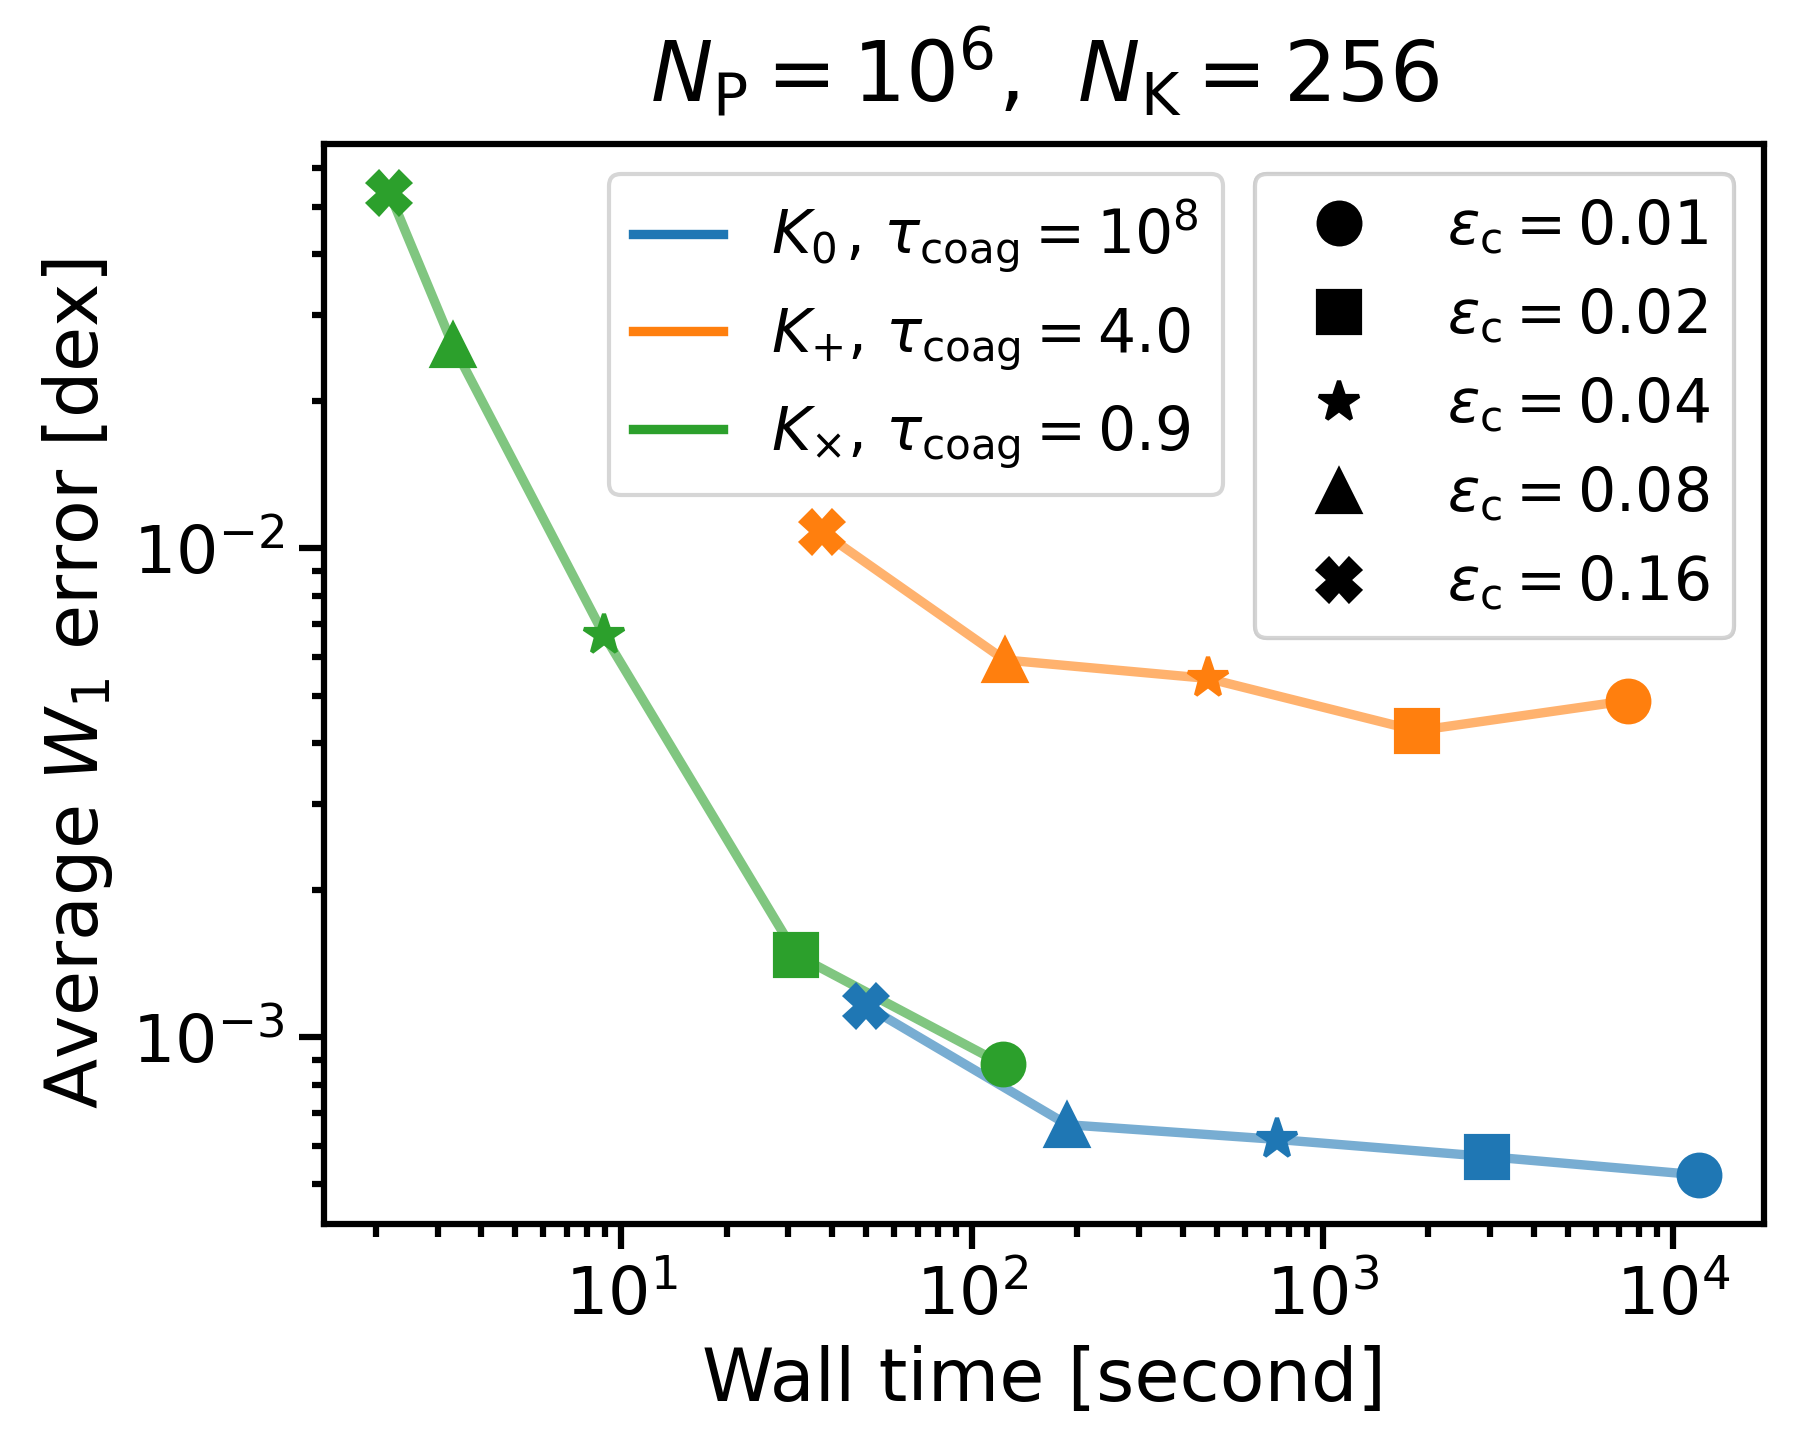

In [71]:
# performance vs error (using cuda)

k_values = [256]
b_values = [0.01, 0.02, 0.04, 0.08, 0.16]
model_list = [f"k{k}_eps{b:.2f}".replace(".", "p") for k, b in product(k_values, b_values)]

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/const/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level_c = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time_c = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/linear/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level_l = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time_l = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper/smoluchowski/product/out')
performance = json.loads((root / 'performance.json').read_text())
model_stats = {entry['model']: entry for entry in performance['models']}

err_level_p = {model: model_stats[model]['w1_log10_mass_dex']['mean'] for model in model_list}
wall_time_p = {model: model_stats[model]['wall_seconds']['mean'] for model in model_list}

n_rows, n_cols = 1, 1
margin_l, margin_r = 1.08, 0.12
margin_b, margin_t = 0.72, 0.48
panel_w, panel_h = 4.8, 3.6
gap_x, gap_y = 0.24, 0.72
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

markers = ['o', 's', '*', '^', 'X']

datasets = [
    (wall_time_c, err_level_c, 'C0', 'Constant kernel'),
    (wall_time_l, err_level_l, 'C1', 'Linear kernel'),
    (wall_time_p, err_level_p, 'C2', 'Product kernel'),
]

for wall_time, err_level, color, label in datasets:

    x = [wall_time[model] for model in model_list]
    y = [err_level[model] for model in model_list]

    axs[0].plot(x, y, color = color, lw = 1.5*linewidth, label = label, alpha = 0.6, zorder = 1)

    for i, marker in enumerate(markers):
        axs[0].plot(x[i], y[i], marker = marker, ms = 10, color = color, ls = 'none', zorder = 2)

kernel_handles = [
    Line2D([0], [0], color = 'C0', lw = 1.5*linewidth, label = '$K_\\mathrm{0\\,}$, $\\tau_\\mathrm{{coag}} = 10^8$'),
    Line2D([0], [0], color = 'C1', lw = 1.5*linewidth, label = '$K_\\mathrm{+}$, $\\tau_\\mathrm{{coag}} = 4.0$'),
    Line2D([0], [0], color = 'C2', lw = 1.5*linewidth, label = '$K_\\mathrm{\\times}$, $\\tau_\\mathrm{{coag}} = 0.9$'),
]
marker_handles = [
    Line2D([0], [0], marker = marker, color = 'k', ls = 'none', ms = 10, label = rf'$\epsilon_\mathrm{{c}} = {b:.2f}$')
    for marker, b in zip(markers, b_values)
]
leg1 = axs[0].legend(handles = kernel_handles, loc = 'upper right', fontsize = 0.9*fontsize, handlelength = 1.5,
    bbox_to_anchor = (0.645, 1), bbox_transform = axs[0].transAxes,)
axs[0].add_artist(leg1)
leg2 = axs[0].legend(handles = marker_handles, loc = 'upper right', fontsize = 0.9*fontsize)
axs[0].add_artist(leg2)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('Wall time [second]', fontsize = 1.1*fontsize)
axs[0].set_ylabel('Average $W_1$ error [dex]', fontsize = 1.1*fontsize)
axs[0].set_title('$N_\\mathrm{P} = 10^6$,  $N_\\mathrm{K} = 256$', fontsize = 1.25*fontsize, pad = 10)
axs[0].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
axs[0].tick_params(axis = 'both', which = 'minor', width = linewidth, length = 3, labelsize = fontsize)
for spine in axs[0].spines.values(): spine.set_linewidth(linewidth)


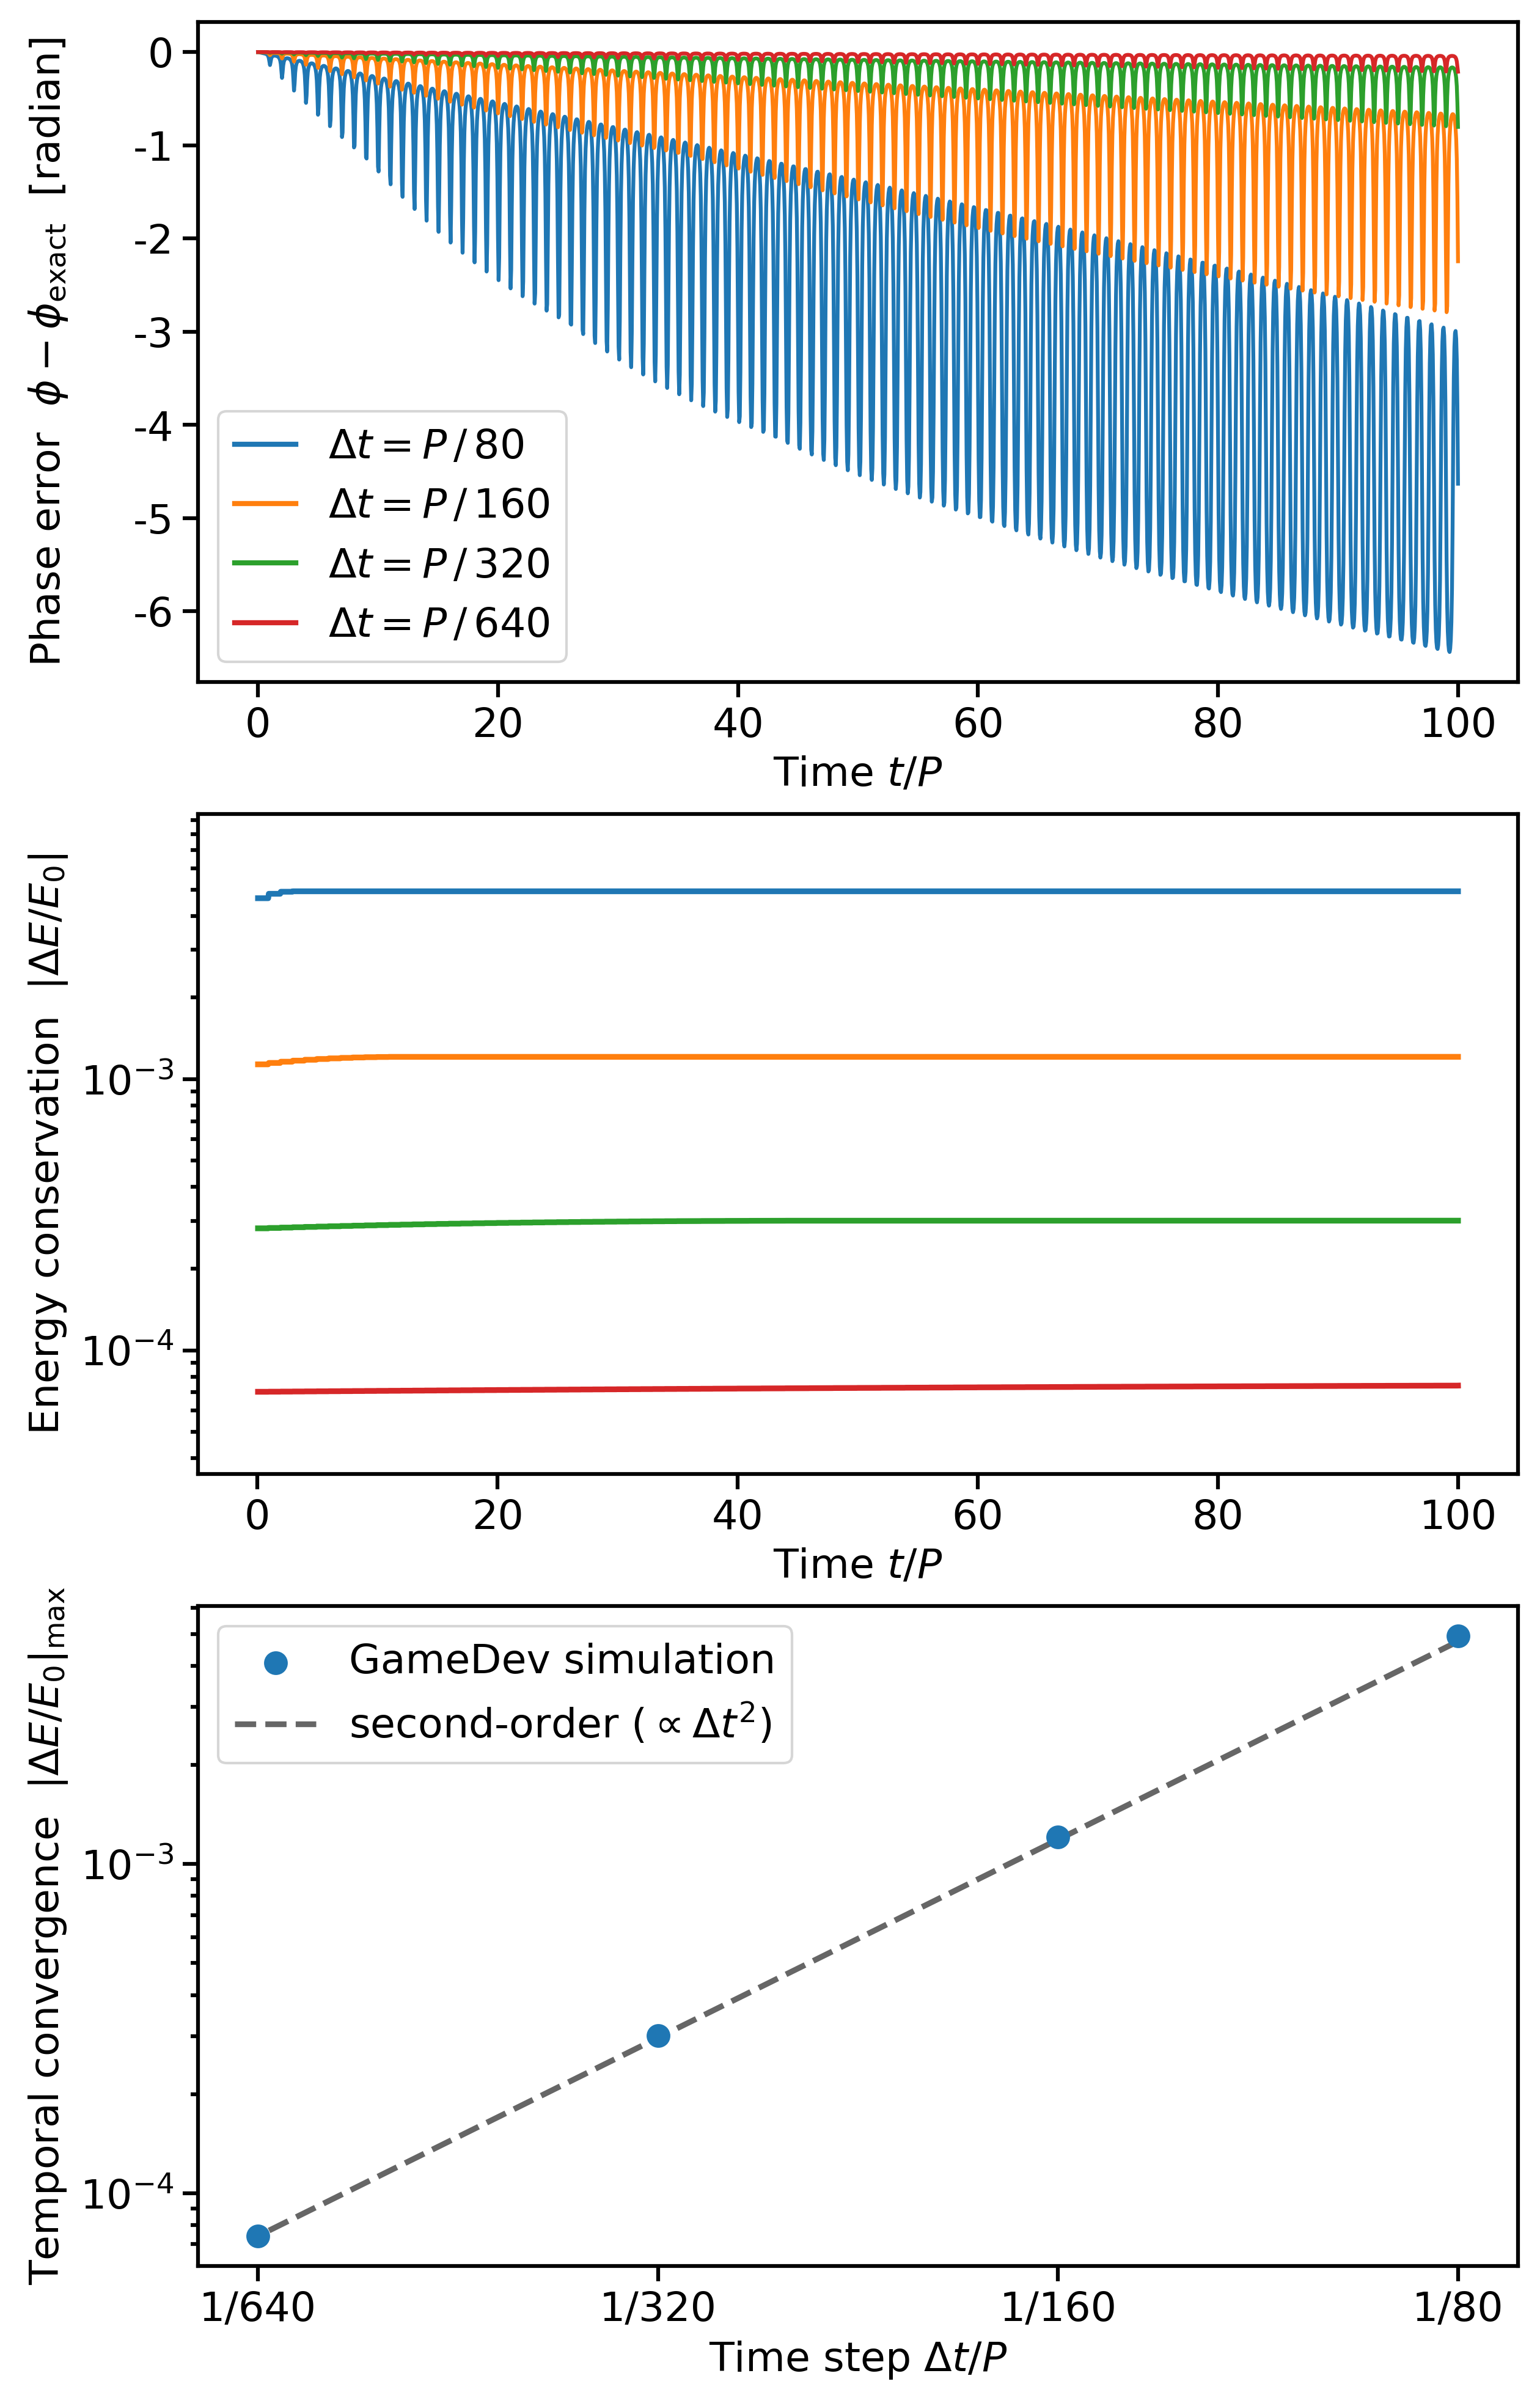

In [55]:
# eccentric orbit test

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper')
backend = 'cuda'

step_values = [80, 160, 320, 640]
model_list = [f'orbit_dt_p{n}' for n in step_values]

n_rows, n_cols = 3, 1
margin_l, margin_r = 1.08, 0.12
margin_b, margin_t = 0.72, 0.12
panel_w, panel_h = 7.2, 3.6
gap_x, gap_y = 0.24, 0.72
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = [fig.add_axes(
    rect_inches(fig, margin_l, margin_b + (n_rows*n_cols - i - 1)*(panel_h + gap_y), panel_w, panel_h)) 
    for i in range(n_rows*n_cols)
]

# Full-precision model schedule: 20 outputs per period, 100 periods
# Avoid phase errors caused by rounded DT_OUT metadata
period = 2*np.pi
time = np.arange(2001)*period / 20
mean_anomaly = (time + np.pi) % (2*np.pi) - np.pi

eccentricity = 0.5
ecc_anomaly = mean_anomaly.copy()
for _ in range(12):
    ecc_anomaly -= (ecc_anomaly - eccentricity*np.sin(ecc_anomaly) - mean_anomaly) / (1 - eccentricity*np.cos(ecc_anomaly))

x_exact = np.cos(ecc_anomaly) - eccentricity
y_exact = np.sqrt(1 - eccentricity**2)*np.sin(ecc_anomaly)
phase_exact = np.unwrap(np.arctan2(y_exact, x_exact))

energy_max = {}

for i, (model, n_step) in enumerate(zip(model_list, step_values)):

    path_model = root / 'ecc_orbit' / 'out' / model / backend
    files = [path_model / f'particle_{j:05d}.dat' for j in range(2001)]

    # Six doubles per particle: phi, r, theta, v_phi, v_r, v_theta.
    data = np.array([np.fromfile(file, dtype = np.float64).reshape(1, 6)[0] for file in files])

    radius = data[:, 1]
    phase = np.unwrap(data[:, 0])

    energy = 0.5*np.sum(data[:, 3:]**2, axis = 1) - 1/radius
    energy_error = np.abs((energy + 0.5)/0.5)
    phase_error = phase - phase_exact

    energy_max[backend, n_step] = energy_error.max()

    axs[0].plot(time / period, phase_error, c = f'C{i}', lw = linewidth, label = f'$\\Delta t = P\,/\,{n_step}$')
    axs[1].plot(time[1:] / period, np.maximum.accumulate(energy_error)[1:], c = f'C{i}', lw = 1.5*linewidth)

available = [n for n in step_values if (backend, n) in energy_max]
if available:
    axs[2].scatter(1 / np.array(available), [energy_max[backend, n] for n in available],
        s = 50, fc = 'C0', ec = 'C0', linewidths = 1.5*linewidth, zorder = 10, label = f'GameDev simulation'
    )

# Anchor the second-order guide to the finest available result.
if energy_max:
    backend_ref, n_ref = max(energy_max, key = lambda key: key[1])
    dt = 1 / np.array(step_values)
    reference = energy_max[backend_ref, n_ref]*(dt*n_ref)**2
    axs[2].plot(dt, reference, c = '0.4', ls = '--', lw = 1.5*linewidth, label = 'second-order ($\\propto \\Delta t^2$)')

axs[0].set_xlabel('Time $t/P$', fontsize = fontsize)
axs[0].set_ylabel('Phase error  $\\phi-\\phi_\\mathrm{exact}$  [radian]', fontsize = fontsize, labelpad = 25)
axs[0].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
for spine in axs[0].spines.values(): spine.set_linewidth(linewidth)
leg = axs[0].legend(fontsize = fontsize, handlelength = 1.5)
for line in leg.get_lines(): line.set_linewidth(2.0)

axs[1].set_yscale('log')
axs[1].set_ylim(3.5e-5, 9.5e-3)
axs[1].set_xlabel('Time $t/P$', fontsize = fontsize)
axs[1].set_ylabel('Energy conservation  $|\\Delta E/E_0|$', fontsize = fontsize)
axs[1].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
axs[1].tick_params(axis = 'both', which = 'minor', width = linewidth, length = 3, labelsize = fontsize)
for spine in axs[1].spines.values(): spine.set_linewidth(linewidth)

axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].legend(fontsize = fontsize)
axs[2].set_xlabel('Time step $\\Delta t/P$', fontsize = fontsize)
axs[2].set_ylabel('Temporal convergence  $|\\Delta E/E_0|_\\mathrm{{max}}$', fontsize = fontsize)
axs[2].set_xticks(1 / np.array(step_values))
axs[2].set_xticklabels([f'1/{n}' for n in step_values])
axs[2].xaxis.set_minor_locator(NullLocator())
axs[2].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
axs[2].tick_params(axis = 'both', which = 'minor', width = linewidth, length = 3, labelsize = fontsize)
for spine in axs[2].spines.values(): spine.set_linewidth(linewidth)


Text(0.010638297872340425, 0.5104166666666666, 'Normalized surface density $\\Sigma_d R_0^2/M_d$')

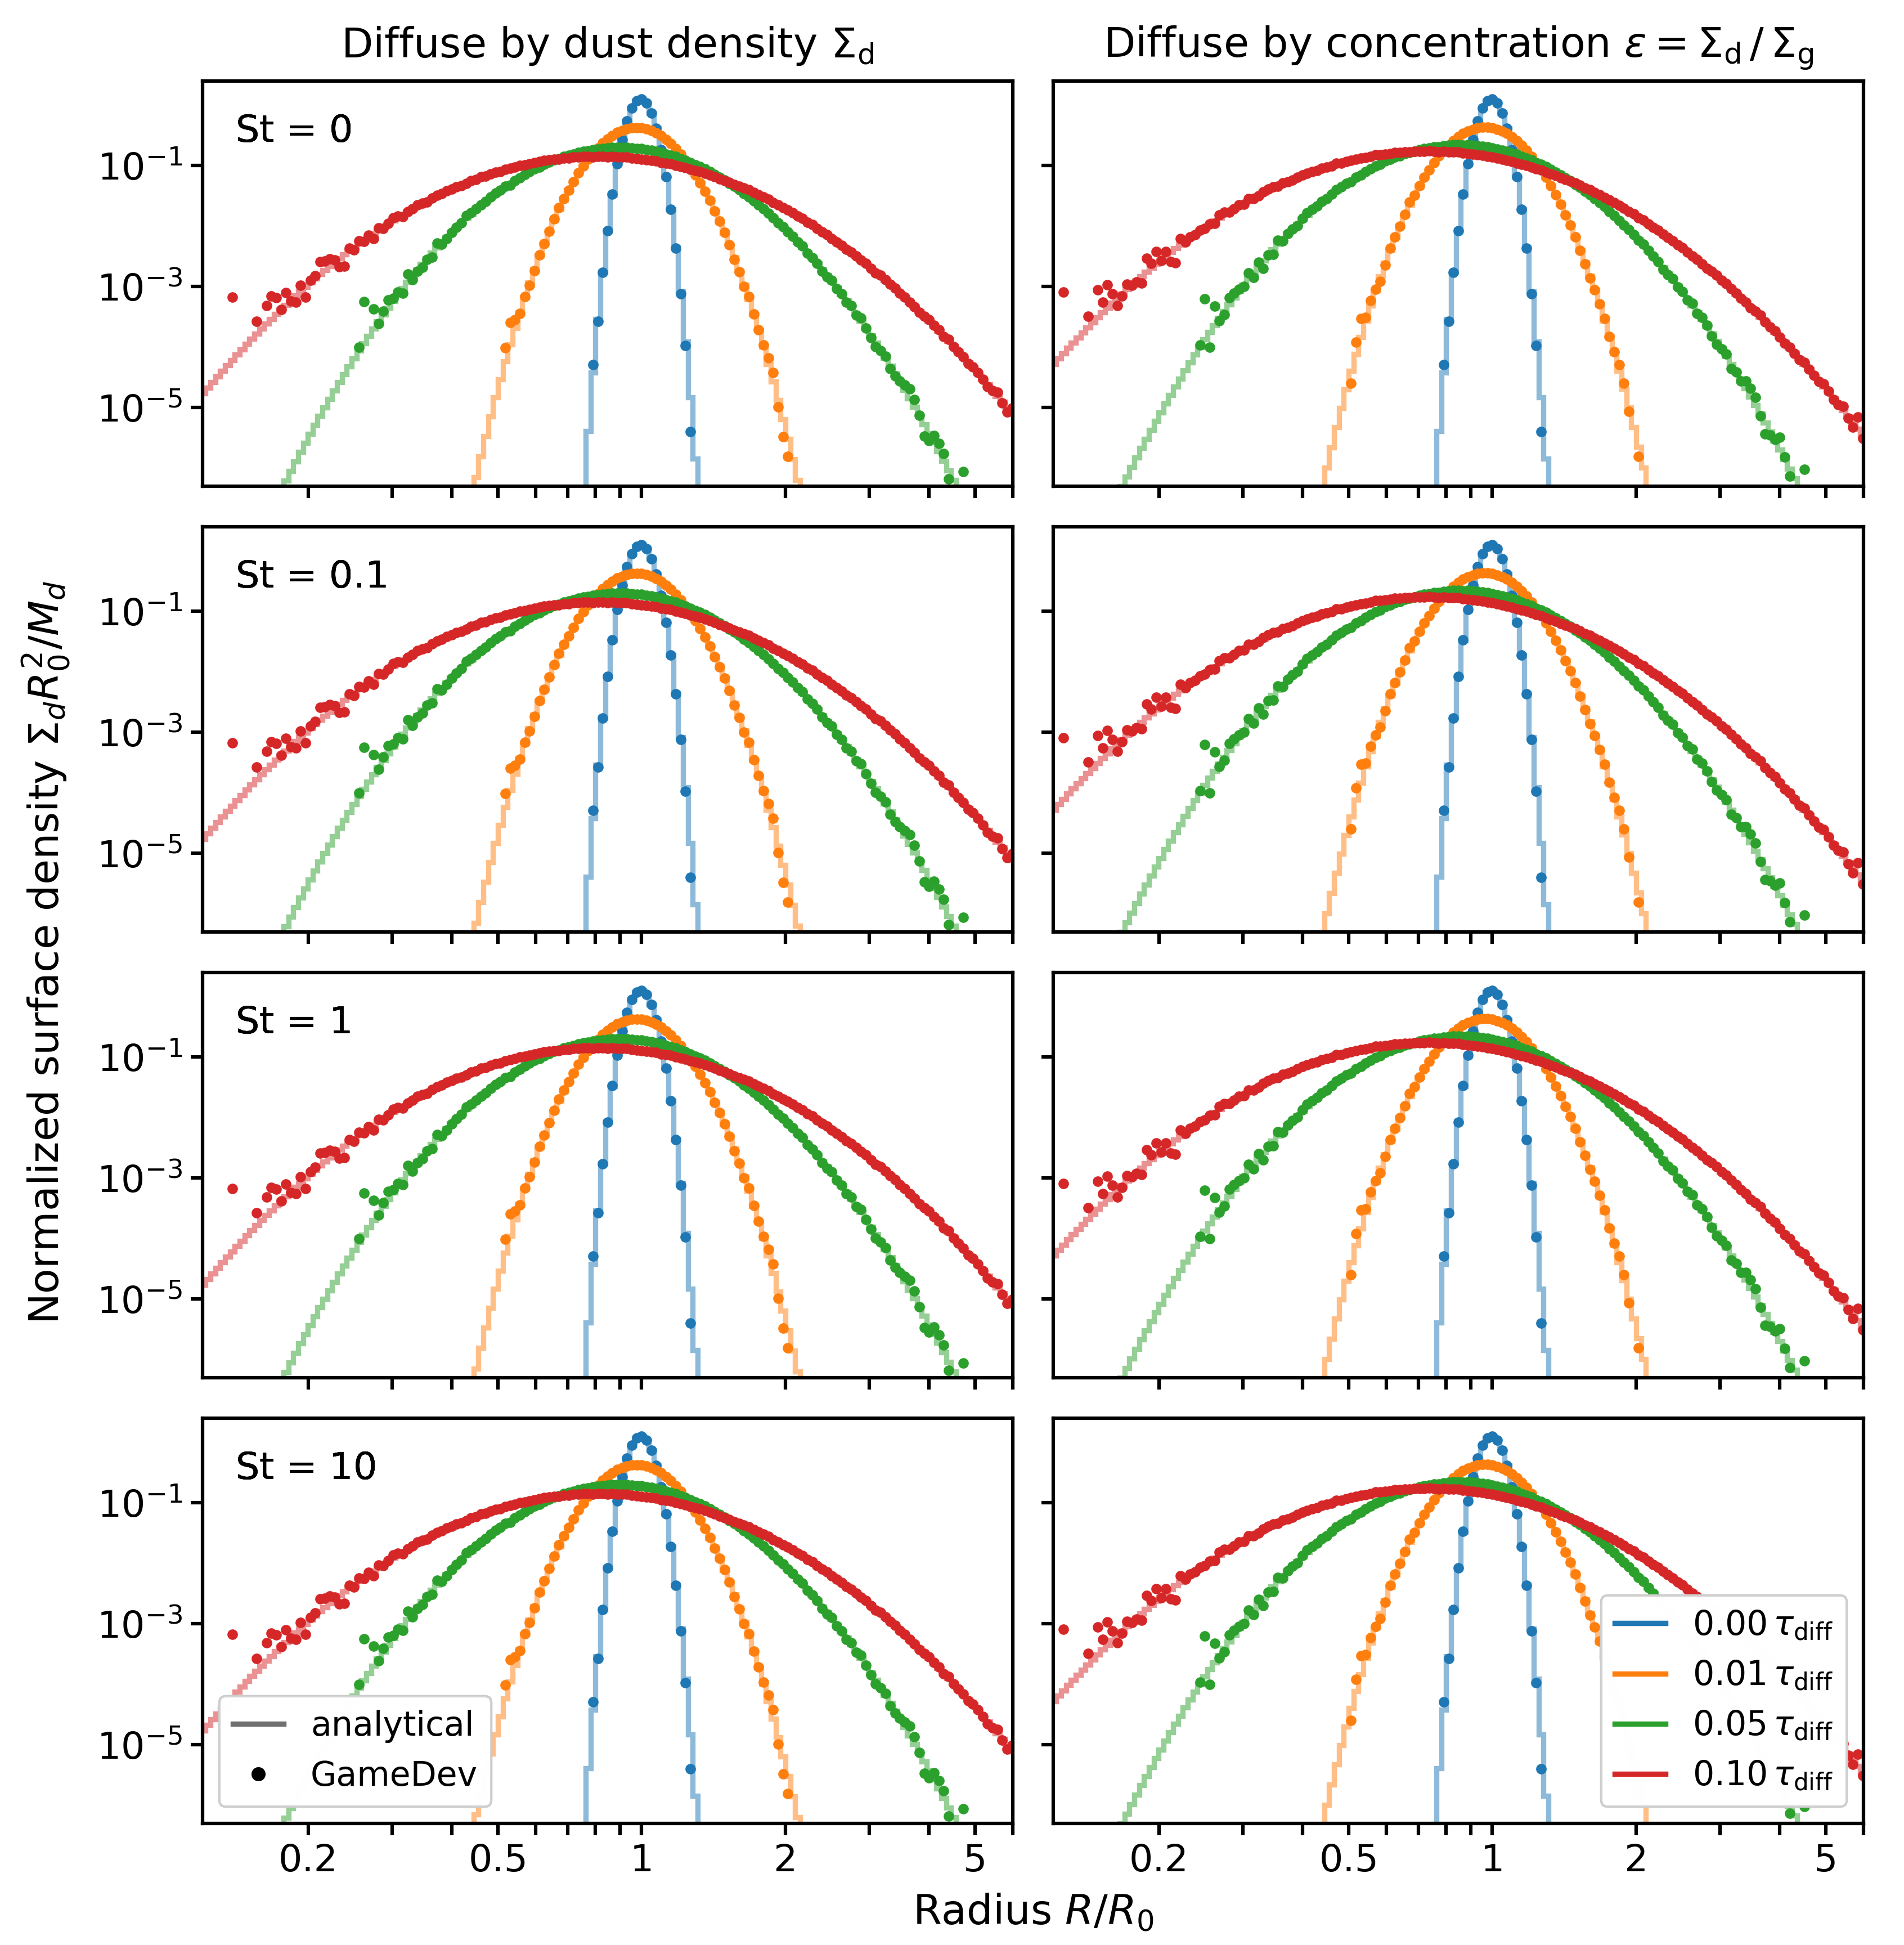

In [59]:
# diffusion test

root = Path('/Users/jiaqingbi/Scratch/gamedev/val/paper')
backend = 'cuda'

mode_values = ['density', 'concentration']
st_values = [0, 0.1, 1, 10]
st_names = ['0', '0p1', '1', '10']
idx_file = [0, 1, 5, 10]

n_rows, n_cols = len(st_values), len(mode_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.48
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

x_min, x_max = 0.12, 6.0
x_bins = np.geomspace(np.exp(-3), np.exp(3), 256)
x_centers = np.sqrt(x_bins[:-1]*x_bins[1:])
annulus_area = np.pi*np.diff(x_bins**2)

for row, (stokes, st_name) in enumerate(zip(st_values, st_names)):
    for col, mode in enumerate(mode_values):

        idx_mod = row*n_cols + col
        model = f'{mode}_st{st_name}'

        for i, snapshot in enumerate(idx_file):

            age = 0.01*snapshot

            # ln(R/R0) is Gaussian; gas surface density is proportional to R^-1.
            mean = (2 if mode == 'density' else 1)*age
            variance = 0.05**2 + 2*age
            z = (np.log(x_bins) - mean)/np.sqrt(2*variance)

            cdf = np.array([0.5*math.erfc(-value) for value in z])
            analytical = np.diff(cdf)/annulus_area

            axs[idx_mod].stairs(analytical, x_bins, label = rf'$at={age:.2f}$', 
                color = f'C{i}', lw = 1.5*linewidth, alpha = 0.5, zorder = 1
            )

            path_model = root / 'diffusion' / 'out' / model / backend
            file = path_model / f'particle_{snapshot:05d}.dat'
            data = np.fromfile(file, dtype = np.float64)

            config = configparser.ConfigParser()
            config.read(path_model / 'variables.txt')
            parameters = config['PARAMETERS']

            n_particles = int(parameters['N_P'])
            time = float(parameters['DT_OUT'])*snapshot
            a = 1e-4 / (1 + stokes**2)

            radius = data.reshape(n_particles, 6)[:, 1]
            counts = np.histogram(radius, bins = x_bins)[0]
            measured = counts / n_particles / annulus_area

            axs[idx_mod].scatter(x_centers, measured,
                s = 5, fc = f'C{i}', ec = f'C{i}', linewidths = 1.5*linewidth, zorder = 2)

            axs[idx_mod].set_xscale('log')
            axs[idx_mod].set_yscale('log')
            axs[idx_mod].set_xlim(x_min, x_max)
            axs[idx_mod].set_ylim(5e-7, 2.5)
            axs[idx_mod].set_xticks([0.2, 0.5, 1, 2, 5])
            axs[idx_mod].set_xticklabels(['0.2', '0.5', '1', '2', '5'])

            axs[idx_mod].yaxis.set_minor_locator(NullLocator())
            axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 5, labelsize = fontsize)
            axs[idx_mod].tick_params(axis = 'both', which = 'minor', width = linewidth, length = 5, labelsize = fontsize)
            for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

            if idx_mod == 0: axs[idx_mod].set_title('Diffuse by dust density $\\Sigma_\\mathrm{d}$', fontsize = 1.1*fontsize, pad = 10)
            if idx_mod == 1: axs[idx_mod].set_title('Diffuse by concentration $\\epsilon = \\Sigma_\\mathrm{d}\\,/\\,\\Sigma_\\mathrm{g}$', fontsize = 1.1*fontsize, pad = 10)
            if idx_mod % n_cols == 0:
                axs[idx_mod].text(0.04, 0.92, f'$\\mathrm{{St}}$ = {stokes}', 
                    # bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'w', ec = 'grey', lw = 0.5*linewidth, alpha = 0.75),
                    transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'left', zorder = 2*len(idx_file)+1
                )
            if idx_mod == (n_rows - 1)*n_cols:
                handles_type = [
                    Line2D([0], [0], color = 'k', lw = 1.5*linewidth, alpha = 0.5, label = 'analytical'),
                    Line2D([0], [0], color = 'k', marker = 'o', ls = 'none', ms = 5, label = 'GameDev')
                ]
                axs[idx_mod].add_artist(axs[idx_mod].legend(handles = handles_type, loc = 'lower left', fontsize = 0.9*fontsize, handlelength = 1.5))
            if idx_mod == n_rows*n_cols - 1:
                handles_time = [
                    Line2D([0], [0], color = f'C{i}', lw = 1.5*linewidth, label = f'${0.01*snapshot:.2f}\,\\tau_\\mathrm{{diff}}$')
                    for i, snapshot in enumerate(idx_file)
                ]
                axs[idx_mod].add_artist(axs[idx_mod].legend(handles = handles_time, loc = 'lower right', fontsize = 0.9*fontsize, handlelength = 1.5))

fig.supxlabel('Radius $R/R_0$', 
    fontsize = 1.1*fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w
)
fig.supylabel('Normalized surface density $\\Sigma_d R_0^2/M_d$',
    fontsize = 1.1*fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h
)
            